In [44]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys

print("Done.")

Done.


In [45]:
option_print = True 

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"] # feature parameters to use
colors = ["red","green","blue","purple","orange","black","pink", "magenta", "turquoise", "cyan", "olive", "brown", "lime", "teal", "khaki", "fuchsia", "navy", "maroon", "gold", "coral"] # colors for each class
num_PCA_components = 2 # number of PCA components to use

pd.set_option('display.max_columns', None)

In [46]:
file_in = "data/unclassified_features_39517_KM_classes_6_s42"

with open(file_in + ".pkl", 'rb') as f:
  feats_df_large = pickle.load(f) # deserialize using load()

print("\n", file_in, " shape: ", feats_df_large.shape)

# these unclassified images are from the proper parameter range
file_in_narrow = "data/unclassified_features_33770"

with open(file_in_narrow + ".pkl", 'rb') as f:
  df_narrow = pickle.load(f)

print("\n", file_in_narrow, " shape: ", df_narrow.shape)


 data/unclassified_features_39517_KM_classes_6_s42  shape:  (39517, 114)

 data/unclassified_features_33770  shape:  (33770, 111)


In [47]:
# Create output directories
output_dir = "data/output_images/"
os.makedirs(output_dir, exist_ok=True)

output_sub_dir = output_dir + file_in[5:] + "/"
os.makedirs(output_sub_dir, exist_ok=True)

specific_file_dir = output_sub_dir + "Visualization_Features_Parameters/"
os.makedirs(specific_file_dir, exist_ok=True)

In [48]:
feats_df = feats_df_large[feats_df_large["path"].isin(df_narrow["path"].unique())]
feats_df.reset_index(inplace = True, drop = True)

print("\nFiltered feats_df with class and narrow bounds: ", feats_df.shape)
feats_df.head()


Filtered feats_df with class and narrow bounds:  (33770, 114)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.426621,5.976980,0
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.593979,6.079593,0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0,2.872217,5.81

In [49]:
# number of classes in clustering
if "cluster" in feats_df.columns:
    num_classes = len(feats_df["cluster"].unique()) 
    print("number of classes: ", num_classes)
else:
    print("Warning: no column called 'cluster' in dataframe")
    

number of classes:  6


In [50]:
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

feats_df = feats_df.copy()
for i in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
    feats_df[i] = feats_df[i].astype(float)

for i in classes:
    df = feats_df[feats_df["cluster"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

    print("Images in class ", i, ": ", class_dfs[i].shape)

Images in class  0 :  (10969, 114)
Images in class  1 :  (9400, 114)
Images in class  2 :  (982, 114)
Images in class  3 :  (10644, 114)
Images in class  4 :  (942, 114)
Images in class  5 :  (833, 114)


In [51]:
feats_df[feats_df.columns[13:111]].columns

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

In [52]:
df_analytics = feats_df.copy()
df_analytics = df_analytics[["Ua", "Ui", "Ga", "Gi", "Da", "Di", "Ba", "path", "dir", "cluster"]]

def tr(Ga_value, Ua_value, Ui_value):
    return Ga_value - Ua_value - Ui_value

def det(Ba_value, Ga_value, Ui_value, Ua_value):
    return Ba_value * Ga_value - Ui_value * (Ga_value-Ua_value)

def T1(Di_value, Ga_value, Ua_value, Da_value, Ui_value):
    return Di_value * (Ga_value - Ua_value) - Da_value * Ui_value

def T2(Di_value, Ga_value, Ua_value, Da_value, Ui_value, Ba_value):
    return (Di_value * (Ga_value - Ua_value) - Da_value * Ui_value) ** 2 - 4 * Da_value * Di_value * det(Ba_value, Ga_value, Ui_value, Ua_value)


# compute these 4 analytics for each image and add to the dataframe
df_analytics["tr"] = df_analytics.apply(lambda row: tr(row["Ga"], row["Ua"], row["Ui"]), axis=1)
df_analytics["det"] = df_analytics.apply(lambda row: det(row["Ba"], row["Ga"], row["Ui"], row["Ua"]), axis=1)
df_analytics["T1"] = df_analytics.apply(lambda row: T1(row["Di"], row["Ga"], row["Ua"], row["Da"], row["Ui"]), axis=1)
df_analytics["T2"] = df_analytics.apply(lambda row: T2(row["Di"], row["Ga"], row["Ua"], row["Da"], row["Ui"], row["Ba"]), axis=1)

print("shape: ", df_analytics.shape)
df_analytics.head(25)

shape:  (33770, 14)


,Ua,Ui,Ga,Gi,Da,Di,Ba,path,dir,cluster,tr,det,T1,T2
0,0.025122,0.063822,0.071957,0.106327,0.009186,0.611871,-0.113131,1.png,/content/Images3/,0,-0.016987,-0.011130,0.028071,0.001038
1,0.034475,0.059956,0.080798,0.100370,0.008852,0.854084,-0.132577,3.png,/content/Images3/,0,-0.013632,-0.013489,0.039034,0.001932
2,0.028367,0.057912,0.073998,0.080784,0.008512,0.534244,-0.133789,7.png,/content/Images3/,0,-0.012281,-0.012543,0.023885,0.000799
3,0.036364,0.055723,0.088968,0.107719,0.011323,0.809702,-0.126763,11.png,/content/Images3/,0,-0.003119,-0.014209,0.041962,0.002282
4,0.035847,0.078762,0.078230,0.101485,0.010542,0.933894,-0.115752,12.png,/content/Images3/,0,-0.036379,-0.012393,0.038751,0.001990
5,0.029837,0.067296,0.079054,0.095099,0.009721,0.822421,-0.132865,13.png,/content/Images3/,0,-0.018079,-0.013816,0.039823,0.002028
6,0.032611,0.066478,0.071324,0.094207,0.008921,0.637970,-0.137396,14.png,/content/Images3/,1,-0.027765,-0.012373,0.024104,0.000863
7,0.023779,0.079529,0.075065,0.084441,0.008201,0.882573,-0.124913,15.png,/content/Images3/,0,-0.028243,-0.013455,0.044612,0.002380
8,0.019285,0.105837,0.157524,0.046954,0.008112,0.503562,-0.132940,17.png,/content/Images3/,3,0.032402,-0.035572,0.068753,0.005308
9,0.025637,0.067777,0.078651,0.117788,0.008538,0.615695,-0.133007,18.png,/content/Images3/,0,-0.014762,-0.014054,0.032062,0.001323


In [53]:
# print the number of images with positive values for each analytic, by class
presentation_order = [1,0,4,5,2,3]
presentation_names = ["No pattern","Reg. spots","Tiger stripes","Inv. tiger stripes","Inverse spots","Full coverage"]  

analytics = ["tr", "det", "T1", "T2"]

for i,name in enumerate(presentation_names):
    print("\nClass: " + name)
    for analytic in analytics:
        num_images = df_analytics[(df_analytics["cluster"] == presentation_order[i]) & (df_analytics[analytic] > 0)].shape[0]
        print (f'# {analytic} > 0 :  {num_images} images')
    
    print()

    for analytic in analytics:
        percent_images = (df_analytics[(df_analytics["cluster"] == presentation_order[i]) & (df_analytics[analytic] > 0)].shape[0]) / df_analytics.shape[0] * 100
        print(f'% {analytic} > 0 :  {percent_images:.2f}% of all images')

    all_positive = df_analytics[(df_analytics["cluster"] == presentation_order[i]) & 
                                (df_analytics["tr"] > 0) & (df_analytics["det"] > 0) & 
                                (df_analytics["T1"] > 0) & (df_analytics["T2"] > 0)].shape[0]
    print("\n --- # all analytics > 0:  " + str(all_positive) + " images")
    print(f" --- % all analytics > 0:  {all_positive/df_analytics.shape[0] * 100:.2f}% of all images")




Class: No pattern
# tr > 0 :  2247 images
# det > 0 :  66 images
# T1 > 0 :  7873 images
# T2 > 0 :  9400 images

% tr > 0 :  6.65% of all images
% det > 0 :  0.20% of all images
% T1 > 0 :  23.31% of all images
% T2 > 0 :  27.84% of all images

 --- # all analytics > 0:  0 images
 --- % all analytics > 0:  0.00% of all images

Class: Reg. spots
# tr > 0 :  3584 images
# det > 0 :  0 images
# T1 > 0 :  10969 images
# T2 > 0 :  10969 images

% tr > 0 :  10.61% of all images
% det > 0 :  0.00% of all images
% T1 > 0 :  32.48% of all images
% T2 > 0 :  32.48% of all images

 --- # all analytics > 0:  0 images
 --- % all analytics > 0:  0.00% of all images

Class: Tiger stripes
# tr > 0 :  353 images
# det > 0 :  0 images
# T1 > 0 :  942 images
# T2 > 0 :  942 images

% tr > 0 :  1.05% of all images
% det > 0 :  0.00% of all images
% T1 > 0 :  2.79% of all images
% T2 > 0 :  2.79% of all images

 --- # all analytics > 0:  0 images
 --- % all analytics > 0:  0.00% of all images

Class: Inv

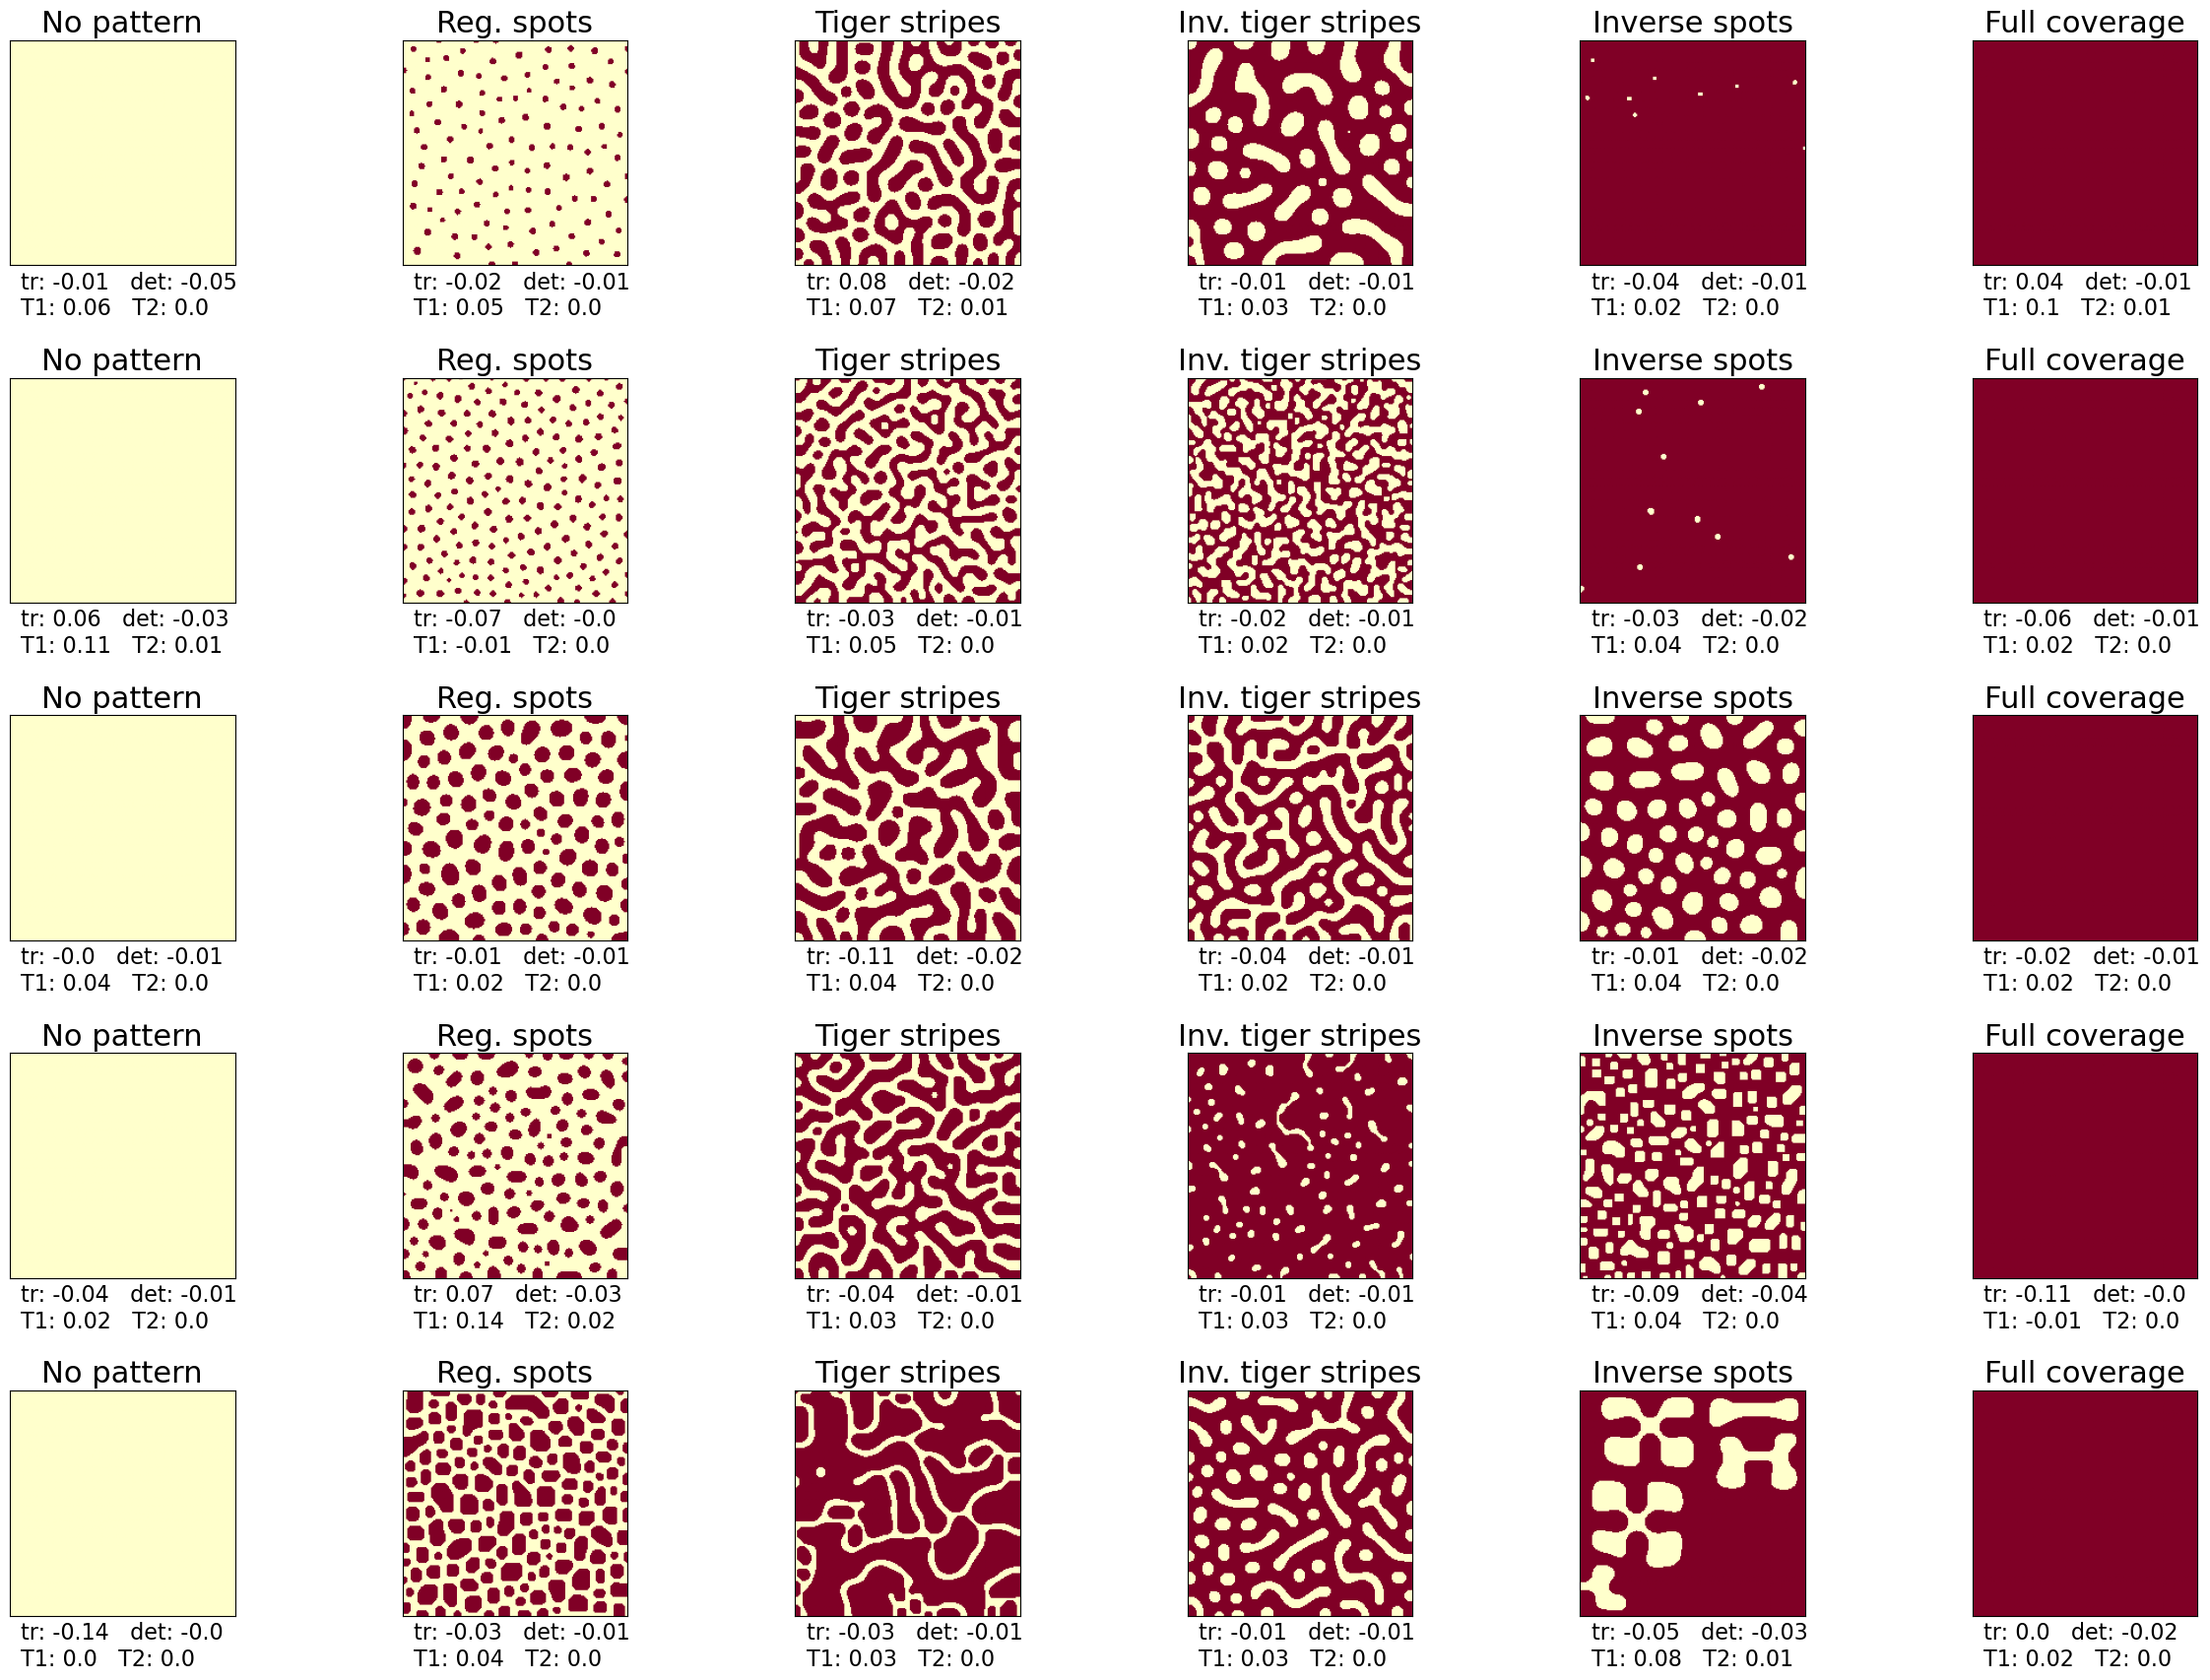

In [54]:
num_imgs = 5
presentation_order = [1,0,4,5,2,3]
presentation_names = ["No pattern","Reg. spots","Tiger stripes","Inv. tiger stripes","Inverse spots","Full coverage"]  

# for legends - use names in the order of original classes display, otherwise mismatch between color and name
legend_presentation_names = ["Reg. spots","No pattern","Inverse spots","Full coverage","Tiger stripes","Inv. tiger stripes"]  

if num_classes != presentation_order.__len__():
    print("Exiting: num_classes != presentation_order length")
    sys.exit()

fig, ax = plt.subplots(num_imgs, presentation_order.__len__())
#fig.suptitle('Classified Images From: ' + file_in, fontsize=36, y=0.97)
plt.subplots_adjust(top=0.75)

analytics = True
for i in range(num_imgs):
  #for j in range(len(class_dfs)):
  for col, j in enumerate(presentation_order):
    df = class_dfs[j]
    if df.shape[0] == 0:
      continue
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path[1:]))
    ax[i][col].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][col].set_title(presentation_names[col], fontsize = 22)
    ax[i][col].get_xaxis().set_visible(False)
    ax[i][col].get_yaxis().set_visible(False)

    if analytics: 
        plt.subplots_adjust(hspace=0.5)
        tr_val = round(df_analytics["tr"].iloc[num], 2)
        det_val = round(df_analytics["det"].iloc[num], 2)
        T1_val = round(df_analytics["T1"].iloc[num], 2)
        T2_val = round(df_analytics["T2"].iloc[num], 2)

        analytics_text = f"tr: {tr_val}   det: {det_val}\nT1: {T1_val}   T2: {T2_val}"
        ax[i][col].text(0.05, -0.22, analytics_text, transform=ax[i][col].transAxes, fontsize=16)

fig.set_figwidth(5*len(class_dfs))
fig.set_figheight(5 * num_imgs)

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "ClassifiedImages_RandomImagesPerClass_cl" + str(num_classes) + ".png", dpi = 300, bbox_inches='tight')
plt.show()

In [55]:
# scaling data for correlation comparison
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# feat_array_scaled contain only features (no image data)
feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:111]]))
print("shape of scaled feature array: ", feat_array_scaled.shape)

shape of scaled feature array:  (33770, 98)


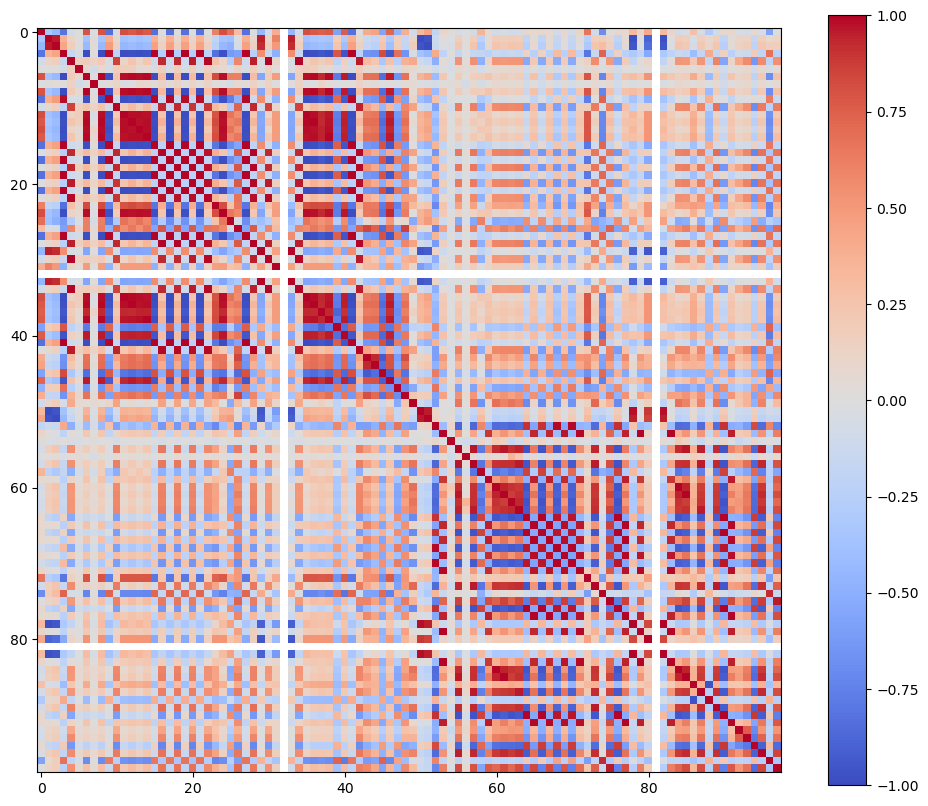

In [56]:
# testing correlation between features for PCA
correlation_matrix = feat_array_scaled.corr()
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

In [57]:
# check correlation between features and their non-inverted counterparts
noninverted_features = feats_df[feats_df.columns[13:62]]

inverted_features = feats_df[feats_df.columns[62:111]]

corr_df_rows = []
pairs = list(zip(noninverted_features.columns, inverted_features.columns))
for noninv, inv in pairs:
    correlation = noninverted_features[noninv].corr(inverted_features[inv])
    corr_df_rows.append({
        "Non-inverted": noninv,
        "Inverted": inv,
        "Correlation": correlation
    })

print("\nCorrelations between non-inverted and inverted features: ")
corr_df = pd.DataFrame(corr_df_rows)
corr_df["Abs Correlation"] = corr_df["Correlation"].abs()
corr_df = corr_df.sort_values(by="Abs Correlation", ascending=False)
corr_df.head(50)


Correlations between non-inverted and inverted features: 


/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,Non-inverted,Inverted,Correlation,Abs Correlation
2,Median,Median_inverted,-1.000000,1.000000
1,Mean,Mean_inverted,-1.000000,1.000000
33,RawIntDen_mean,RawIntDen_inverted_mean,-0.899514,0.899514
29,IntDen_mean,IntDen_inverted_mean,-0.899514,0.899514
23,Angle_mean,Angle_inverted_mean,0.734492,0.734492
26,Circ._std,Circ._inverted_std,0.728444,0.728444
48,Solidity_std,Solidity_inverted_std,0.575317,0.575317
45,Round_mean,Round_inverted_mean,0.484213,0.484213
25,Circ._mean,Circ._inverted_mean,-0.469011,0.469011
47,Solidity_mean,Solidity_inverted_mean,0.451305,0.451305


In [64]:

# calculate the pearson correlation coefficients
correlation_coefficients = correlation_matrix.values

correlations = []
# print all correlations
for i in range(correlation_coefficients.shape[0]):
   for j in range(i+1, correlation_coefficients.shape[1]):
           correlations.append((feats_df.columns[13:111][i], feats_df.columns[13:111][j], correlation_coefficients[i][j]))

all_corr = pd.DataFrame(correlations, columns=["Feature 1", "Feature 2", "Correlation"])
all_corr["Abs_Correlation"] = all_corr["Correlation"].abs()
all_corr = all_corr.sort_values(by="Abs_Correlation", ascending=False)

all_corr.head(20)


,Feature 1,Feature 2,Correlation,Abs_Correlation
3792,Area_inverted_std,RawIntDen_inverted_std,1.000000,1.000000
3788,Area_inverted_std,IntDen_inverted_std,1.000000,1.000000
2478,IntDen_std,RawIntDen_std,1.000000,1.000000
241,Median,Median_inverted,-1.000000,1.000000
411,Area_std,RawIntDen_std,1.000000,1.000000
4585,IntDen_inverted_std,RawIntDen_inverted_std,1.000000,1.000000
2410,IntDen_mean,RawIntDen_mean,1.000000,1.000000
4566,IntDen_inverted_mean,RawIntDen_inverted_mean,1.000000,1.000000
407,Area_std,IntDen_std,1.000000,1.000000
145,Mean,Mean_inverted,-1.000000,1.000000


In [59]:
# find out the most highly (>0.7 or <-0.7) correlated features
highly_correlated_df = all_corr[all_corr["Abs_Correlation"] > 0.7]
highly_correlated_df = highly_correlated_df.sort_values(by="Abs_Correlation", ascending=False)

print("\n\n", highly_correlated_df.shape[0], " highly correlated features")
highly_correlated_df.head(20)




 777  highly correlated features


,Feature 1,Feature 2,Correlation,Abs_Correlation
3792,Area_inverted_std,RawIntDen_inverted_std,1.000000,1.000000
3788,Area_inverted_std,IntDen_inverted_std,1.000000,1.000000
2410,IntDen_mean,RawIntDen_mean,1.000000,1.000000
407,Area_std,IntDen_std,1.000000,1.000000
4585,IntDen_inverted_std,RawIntDen_inverted_std,1.000000,1.000000
411,Area_std,RawIntDen_std,1.000000,1.000000
4566,IntDen_inverted_mean,RawIntDen_inverted_mean,1.000000,1.000000
241,Median,Median_inverted,-1.000000,1.000000
2478,IntDen_std,RawIntDen_std,1.000000,1.000000
145,Mean,Mean_inverted,-1.000000,1.000000


In [60]:
# drop highly correlated features for PCA
features_to_drop = set()

cutoff = 0.85
feats_to_drop_df = highly_correlated_df[highly_correlated_df["Abs_Correlation"] > cutoff]

for i, row in feats_to_drop_df.iterrows():
    features_to_drop.add(row["Feature 1"])

print("number of dropped features: ", len(features_to_drop))

feats_df_reduced = feats_df.drop(columns=features_to_drop)

# new df after dropping features
print("shape of reduced df: ", feats_df_reduced.shape)
feats_df_reduced.head()

number of dropped features:  72
shape of reduced df:  (33770, 42)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,99.395943,97.530229,55.108900,0.958686,100.0,0.0,120.129000,0.564778,0.183575,0.115368,0.879486,0.067138,1,99.998,100.022,38.796,100.0,0.0,9980445.0,45.0,0.0,1.001,0.0,0.979,0.0,3.426621,5.976980,0
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,101.800571,99.451270,56.049556,0.999619,100.0,0.0,120.191190,0.613529,0.226780,0.127976,0.954905,0.046408,1,99.992,100.015,72.380,100.0,0.0,10003140.0,135.0,0.0,1.000,0.0,0.981,0.0,2.593979,6.079593,0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,100.557675,98.103338,29.220831,0.992974,100.0,0.0,133.450130,0.375951,0.220792,0.129524,0.946805,0.050966,1,99.987,100.001,5.766,100.0,0.0,10012320.0,45.0,0.0,1.000,0.0,0.982,0.0,2.872217,5.813336,0
3,0.036364,0.055723,0.088968,0.107719,-0.126763,0.011323,0.809702,1,2,11.png,11,/content/Images3/,1,60,100.278917,96.623433,31.876883,0.998600,100.0,0.0,121.100333,0.640095,0.255338,0.147520,0.879717,0.052488,1,99.996,100.058,126.215,100.0,0.0,10042920.0,135.0,0.0,1.000,0.0,0.985,0.0,2.715196,6.082220,0
4,0.035847,0.078762,0.078230,0.101485,-0.115752,0.010542,0.933894,1,2,12.png,12,/content/Images3/,1,73,103.192973,99.320973,58.915521,0.997630,100.0,0.0,110.340836,0.731391,0.188294,0.110053,0.912808,0.037124,1,99.972,100.015,57.708,100.0,0.0,9882780.0,135.0,0.0,1.000,0.0,0.969,0.0,2.720425,6.088014,0


In [61]:

# Applying PCA function on reduced data after dropping highly correlated features
print("\n\nPCA on reduced dataframe:")
from sklearn.decomposition import PCA

pca = PCA(n_components = num_PCA_components)
end_feats = feats_df_reduced.shape[1] - 3

# scale the new reduced features
reduced_array_scaled = pd.DataFrame(sc.fit_transform(feats_df_reduced[feats_df_reduced.columns[13:end_feats]]))
print("shape of reduced scaled array: ", reduced_array_scaled.shape)


pca_data = pca.fit_transform(reduced_array_scaled)

explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance: ", explained_variance)

# drop pc3 column if 2 components for less confusion
if num_PCA_components == 2 and "pc3" in feats_df_reduced.columns:
    feats_df_reduced.drop(columns = ["pc3"], inplace = True)

for j in range(num_PCA_components):
    feats_df_reduced["pc"+str(j+1)] = pca_data[:,j]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df_reduced[feats_df_reduced["cluster"] == i]
    for j in range(num_PCA_components):
        class_dfs[i].loc[:,"pc" + str(j+1)] = class_subset["pc" + str(j+1)].values

# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=reduced_array_scaled.columns)

print("\nPCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

# print top features and their loadings for each PC
for j in range(num_PCA_components):
   print("PC" + str(j+1)+ ":")
   for feat in top_features["PC"+str(j+1)]:
       print(f"----{feats_df_reduced.columns[feat + 13]};   loading: {loadings.loc[feat, "PC" + str(j+1)]}")



PCA on reduced dataframe:
shape of reduced scaled array:  (33770, 26)

Explained Variance:  [0.32704176 0.15427178]

PCA Loadings:
             PC1           PC2
0   2.268489e-01  3.055834e-01
1   3.897351e-02 -3.950763e-02
2   1.200744e-02 -5.846903e-02
3   3.184078e-01  6.235782e-02
4   8.073129e-02  4.321609e-01
5   1.608017e-01 -2.644381e-02
6   0.000000e+00 -2.168404e-19
7  -3.016172e-01 -7.307653e-02
8   1.817753e-01 -2.812058e-01
9   2.792219e-01  3.314561e-02
10  3.262133e-01  1.491352e-01
11 -2.860960e-01  4.752869e-02
12  2.844067e-01 -7.482056e-02
13  1.067826e-01 -2.600590e-01
14 -2.010070e-02  5.186494e-02
15  1.886094e-02 -4.071994e-02
16  2.772743e-01  1.560294e-01
17  1.851618e-01  1.811630e-01
18 -2.168741e-30  6.647652e-26
19  3.240097e-02  3.335636e-01
20 -1.789336e-01 -6.651029e-03
21  1.689586e-01 -1.937704e-01
22  1.293767e-01 -2.887170e-01
23  1.595954e-01 -3.420247e-01
24 -2.683238e-01 -8.340378e-02
25  2.069685e-01 -3.307267e-01

Top Contributing Features per

In [62]:
# will show PCA columns added to feats_df
feats_df_reduced.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,99.395943,97.530229,55.108900,0.958686,100.0,0.0,120.129000,0.564778,0.183575,0.115368,0.879486,0.067138,1,99.998,100.022,38.796,100.0,0.0,9980445.0,45.0,0.0,1.001,0.0,0.979,0.0,2.253881,1.402570,0
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,101.800571,99.451270,56.049556,0.999619,100.0,0.0,120.191190,0.613529,0.226780,0.127976,0.954905,0.046408,1,99.992,100.015,72.380,100.0,0.0,10003140.0,135.0,0.0,1.000,0.0,0.981,0.0,1.325893,1.708478,0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,100.557675,98.103338,29.220831,0.992974,100.0,0.0,133.450130,0.375951,0.220792,0.129524,0.946805,0.050966,1,99.987,100.001,5.766,100.0,0.0,10012320.0,45.0,0.0,1.000,0.0,0.982,0.0,1.273507,1.488691,0
3,0.036364,0.055723,0.088968,0.107719,-0.126763,0.011323,0.809702,1,2,11.png,11,/content/Images3/,1,60,100.278917,96.623433,31.876883,0.998600,100.0,0.0,121.100333,0.640095,0.255338,0.147520,0.879717,0.052488,1,99.996,100.058,126.215,100.0,0.0,10042920.0,135.0,0.0,1.000,0.0,0.985,0.0,1.908427,1.804419,0
4,0.035847,0.078762,0.078230,0.101485,-0.115752,0.010542,0.933894,1,2,12.png,12,/content/Images3/,1,73,103.192973,99.320973,58.915521,0.997630,100.0,0.0,110.340836,0.731391,0.188294,0.110053,0.912808,0.037124,1,99.972,100.015,57.708,100.0,0.0,9882780.0,135.0,0.0,1.000,0.0,0.969,0.0,1.547608,1.687523,0


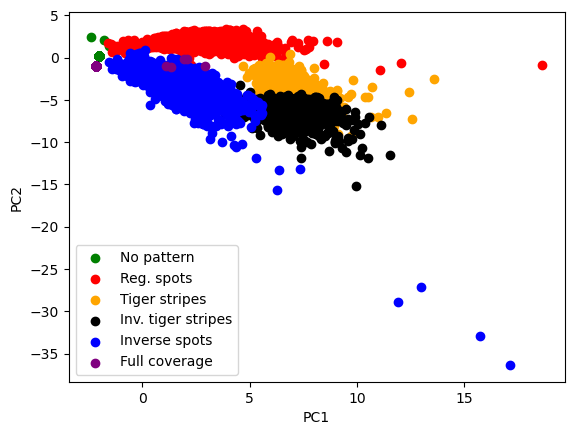

In [ ]:
# plot the model predicted class in feature space
folder_name = "PCA_of_Features/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

import plotly.graph_objects as go

feat_1 = "pc1"
feat_2 = "pc2"

alpha = [1,1,1,1,1,1,1,1,1,1]

if num_PCA_components == 2:
  fig, ax = plt.subplots()
  for j in presentation_order:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

  leg = ax.legend(loc="lower left")
  ax.set(xlabel = "PC1", ylabel = "PC2", title = "")

  # option_print = True
  # if option_print:
  #   plt.savefig(specific_file_dir + folder_name + "PCA_of_Feats_2_Components.png", dpi = 300, bbox_inches='tight')
  plt.show()

Exploration of combos of points in 2D and 3D

In [ ]:
# set feats_df to the reduced version for future use in other cells
feats_df = feats_df_reduced.copy()

In [14]:
# PCA on parameters
print("\n\nPCA on parameters:")
num_PCA_P_components = 2

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# param_array_scaled contain only 7 paramaters
param_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[0:7]]))
print(param_array_scaled.shape)

# Applying PCA function on training and testing set of X component
from sklearn.decomposition import PCA

pca_p = PCA(n_components = num_PCA_P_components)
pca_data_p = pca_p.fit_transform(param_array_scaled)

explained_variance_p = pca_p.explained_variance_ratio_
print(explained_variance_p)

# drop pcp3 column if 2 components for less confusion
if num_PCA_P_components == 2 and "pcp3" in feats_df.columns:
    feats_df.drop(columns = ["pcp3"], inplace = True)

for j in range(num_PCA_P_components):
    feats_df["pcp"+str(j+1)] = pca_data_p[:,j]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for j in range(num_PCA_P_components):
        class_dfs[i].loc[:,"pcp" + str(j+1)] = class_subset["pcp" + str(j+1)].values

# PCA components (loadings)
loadings_p = pd.DataFrame(pca_p.components_.T,
                          columns=[f'PC{i+1}' for i in range(len(pca_p.components_))],
                          index=param_array_scaled.columns)

print("PCA in parameters space Loadings:")
print(loadings_p)

# Find top features for each principal component
top_parameters = {}
for pc in loadings_p.columns:
    top_parameters[pc] = loadings_p[pc].abs().nlargest(3).index.tolist() # Top 3 contributing features
print("\nTop Contributing Parameters per Principal Component:")
print(top_parameters)

for j in range(num_PCA_P_components):
    print("PC" + str(j+1)+ ":")
    for par in top_parameters["PC"+str(j+1)]:
        print(f"----{feats_df.columns[par]}")



PCA on parameters:
(33770, 7)
[0.1493331  0.14579587]
PCA in parameters space Loadings:
        PC1       PC2
0  0.031218  0.678894
1  0.595812 -0.190118
2  0.465675  0.245693
3  0.212672 -0.375764
4 -0.164413 -0.239706
5  0.009239  0.493369
6  0.595679  0.022855

Top Contributing Parameters per Principal Component:
{'PC1': [1, 6, 2], 'PC2': [0, 5, 3]}
PC1:
----Ui
----Di
----Ga
PC2:
----Ua
----Da
----Gi


In [15]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,pcp1,pcp2
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,0,-1.248846,-0.780791
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,0,-0.693879,-0.132873
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,20

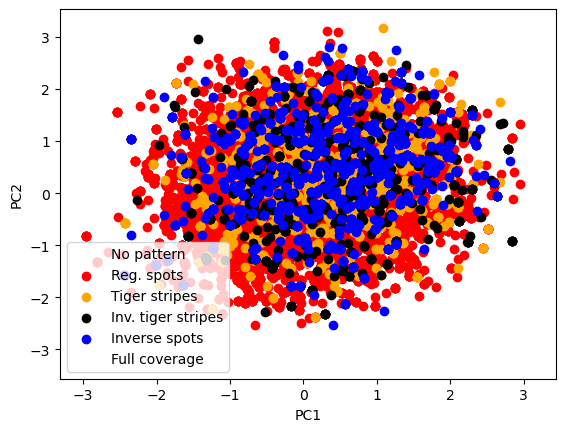

In [16]:
# plot the model predicted class in prameters space
folder_name = "PCA_of_Parameters/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

import plotly.graph_objects as go

component_1 = "pcp1"
component_2 = "pcp2"

alpha = [1,0,1,0,1,1,1,1,1,1]


if num_PCA_P_components == 2:
    fig, ax = plt.subplots()
    for j in presentation_order:
        df = class_dfs[j]
        ax.scatter(df[component_1], df[component_2], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

    leg = ax.legend(loc="lower left")
    ax.set(xlabel = "PC1", ylabel = "PC2", title = "")

    # option_print = True
    if option_print:
        plt.savefig(specific_file_dir + folder_name + "PCA_of_Params_2_Components.png", dpi = 300, bbox_inches='tight')
        plt.show()

if num_PCA_P_components == 3:
    component_3 = "pcp3"

    # 3D matplotlib plot
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    for j in presentation_order:
        df = class_dfs[j]
        ax.scatter3D(df[component_1], df[component_2], df[component_3], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = component_1, ylabel = component_2, zlabel = component_3)
    ax.view_init(30,45)

    # enhanced 3D plot with plotly
    traces = []
    for i in presentation_order:
        df = class_dfs[i]
        color = colors[i]
        cur_alpha = alpha[i]

        trace = go.Scatter3d(x=df[component_1],y=df[component_2],z=df[component_3], name=legend_presentation_names[i], mode='markers',
            marker=dict(
                size=5,
                color=color,
                opacity=cur_alpha
            )
        )
        traces.append(trace)

    fig = go.Figure(data=traces)
    fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
    fig.update_layout(scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
    ))
    # option_print = True
    if option_print:
        plt.savefig(specific_file_dir + folder_name + "PCA_of_Params_3_Components.png", dpi = 300, bbox_inches='tight')
        fig.write_html(specific_file_dir + folder_name + "Interactive_Plot_PCA_of_Params_3_Components.html")
        fig.show()

In [17]:
# plot the model predicted class in feature space
print("\n\nNow plotting parameter vs parameter combinations: ")

folder_name = "Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

from itertools import combinations

def plotter(feat_1,feat_2):
  fig, ax = plt.subplots()

  alpha = [1,0,1,0,1,1,1,1,1,1] # opacity of points
  for j in presentation_order:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(title = feat_2 + " vs " + feat_1, xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300)
    plt.close()
  else:
    plt.show()
  return

for p1,p2 in combinations(params, 2):
  plotter(p1,p2)

if option_print:
  print("2D Parameter plots are saved.")



Now plotting parameter vs parameter combinations: 
2D Parameter plots are saved.


In [18]:
# do clusters in 3 parameters in 3D
print("\n\nNow plotting parameter vs parameter vs parameter combinations: ")

folder_name = "Parameter_vs_Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def threeD_plotter(feat_1,feat_2,feat_3):
    # 3D matplotlib plot
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    alpha = [1,1,1,1,1,1,0]
    for j in presentation_order:
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    ax.view_init(30, 90)

    # enhanced 3D plot with plotly
    traces = []

    for i in presentation_order:
      df = class_dfs[i]
      color = colors[i]
      cur_alpha = alpha[i]
    
      trace = go.Scatter3d(x=df[feat_1],y=df[feat_2],z=df[feat_3], name=legend_presentation_names[i], mode='markers',
          marker=dict(
              size=5,
              color=color,
              opacity=cur_alpha
          ))
      traces.append(trace)

    fig = go.Figure(data=traces)
    fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
    #fig.show()
    
    option_print = True
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + "_vs_" + feat_3 + ".png", dpi = 300, bbox_inches='tight')
      fig.write_html(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + "_vs_" + feat_3 + "_Interactive.html")
      plt.close()
    else:
      plt.show()

for p1,p2,p3 in combinations(params, 3):
  threeD_plotter(p1,p2,p3)

if option_print:
  print("3D Parameter plots are saved.")



Now plotting parameter vs parameter vs parameter combinations: 
3D Parameter plots are saved.


In [19]:
# plot ratios of params
print("\n\nNow plotting ratios of parameters: ")

folder_name = "Ratios_of_Parameters_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def ratio_plotter(feat_1,feat_2):
  for p in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == p]
    class_dfs[p].loc[:, p0 + "/" + p1] = class_subset[p0 + "/" + p1].values
    class_dfs[p].loc[:, p2 + "/" + p3] = class_subset[p2 + "/" + p3].values

  fig, ax = plt.subplots()

  alpha = [1,0,1,0,1,1,1,1,1,1]
  for j in presentation_order:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  feat_1_name = feat_1.replace("/","-")
  feat_2_name = feat_2.replace("/","-")
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1_name + "_vs_" + feat_2_name + "_Ratios.png", dpi = 300, bbox_inches='tight')
    plt.close()
  else:
    plt.show()
  return

plot=1
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ratio_1 = np.array(feats_df[p0]) / np.array(feats_df[p1])
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]) / np.array(feats_df[p3])
          feats_df[p2 + "/" + p3] = ratio_2
          class_dfs = [df.copy() for df in class_dfs]
          
          if plot:
            ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

if option_print:
  print("Ratios of parameters plots are saved.")



Now plotting ratios of parameters: 
280
Ratios of parameters plots are saved.


In [20]:
# shows parameter ratio columns
feats_df.columns[116:137]

Index(['Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba', 'Ui/Ga'],
      dtype='object')

In [ ]:
# print bar plots for each param based on class
print("\n\nNow plotting mean feature and parameter values by class: ")

folder_name = "Mean_Feat_Param_Values_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:end_feats])

classes = np.arange(0,num_classes)# list of unique clusters
rows = {str(i): [] for i in classes}

for i in range(len(feats)):
  fig, ax = plt.subplots()

  param = feats[i]
  data = []
  
  for i in presentation_order:
    df = class_dfs[i]
    rows[str(i)] = df[param].values
    data.append(rows[str(i)])

  positions = np.arange(0, num_classes) * 2.5

  # outliers not shown; to show outliers, set showfliers=True
  bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
              medianprops=dict(color='black'))

  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
  ax.set(title = "Mean " + param)
  tick_labels = [i for i in presentation_names]
  ax.set_xticklabels(tick_labels)
  plt.xticks(fontsize=7.5)

  # option_print = True
  if option_print:
    if "/" in param:
      param = param.replace("/","-")
      param = param + "_Ratio"
    plt.savefig(specific_file_dir + folder_name + "Mean_" + param + ".png", dpi = 300,  bbox_inches='tight')
    plt.close()
  else:
    plt.show()
  
if option_print:
  print("Mean parameter box plots are saved.")



Now plotting mean feature and parameter values by class: 
Mean parameter box plots are saved.


In [274]:
# scale each param to plot them next to each other
from sklearn.preprocessing import MinMaxScaler

ratios = feats_df.columns[116:137]

params_df = feats_df[params]
for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled

feats_scaled = feats_df.columns[137:144]

ratios_df = feats_df[ratios]
for ratio in  ratios:
  sc = MinMaxScaler()
  ratio_arr = np.array(ratios_df[ratio]).reshape(-1,1)
  ratio_arr_scaled = sc.fit_transform(ratio_arr)
  feats_df[ratio + "_scaled"] = ratio_arr_scaled

ratios_scaled = feats_df.columns[-len(ratios):-1]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for feat in feats_scaled:
        class_dfs[i].loc[:, feat] = class_subset[feat].values
    for ratio in ratios_scaled:
        class_dfs[i].loc[:, ratio] = class_subset[ratio].values



Now plotting a scaled ratio: 


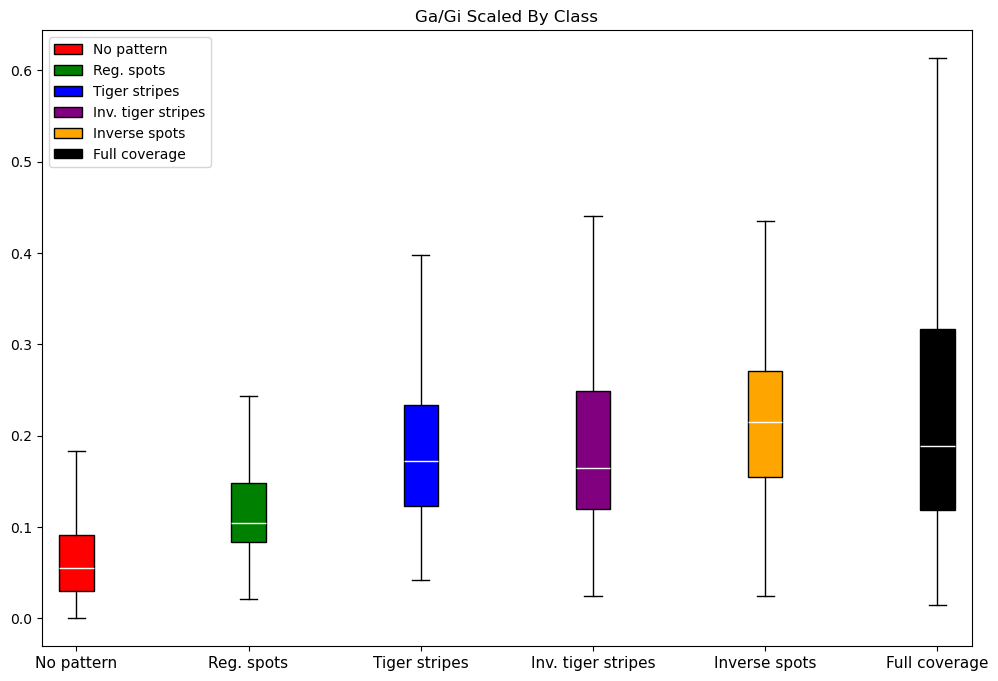

In [ ]:
print("\n\nNow plotting a scaled ratio: ")

ratios_list = ["Ga/Gi_scaled"]

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (12,8))
data = []

for i in presentation_order:
  class_df = class_dfs[i]

  for feat in ratios_list:
    df = class_df[feat]
    data.append(df)

positions = np.arange(0, num_classes) * 2.5  + 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='white'))

for patch, color in zip(bp['boxes'], colors):
  patch.set_facecolor(color)
    
ax.set(title = "Ga/Gi Scaled By Class")
ax.set_xticks(positions)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(presentation_names, loc="upper left")
leg = ax.get_legend()

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Scaled_Param_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()



Now plotting mean scaled parameter ratios by class: 


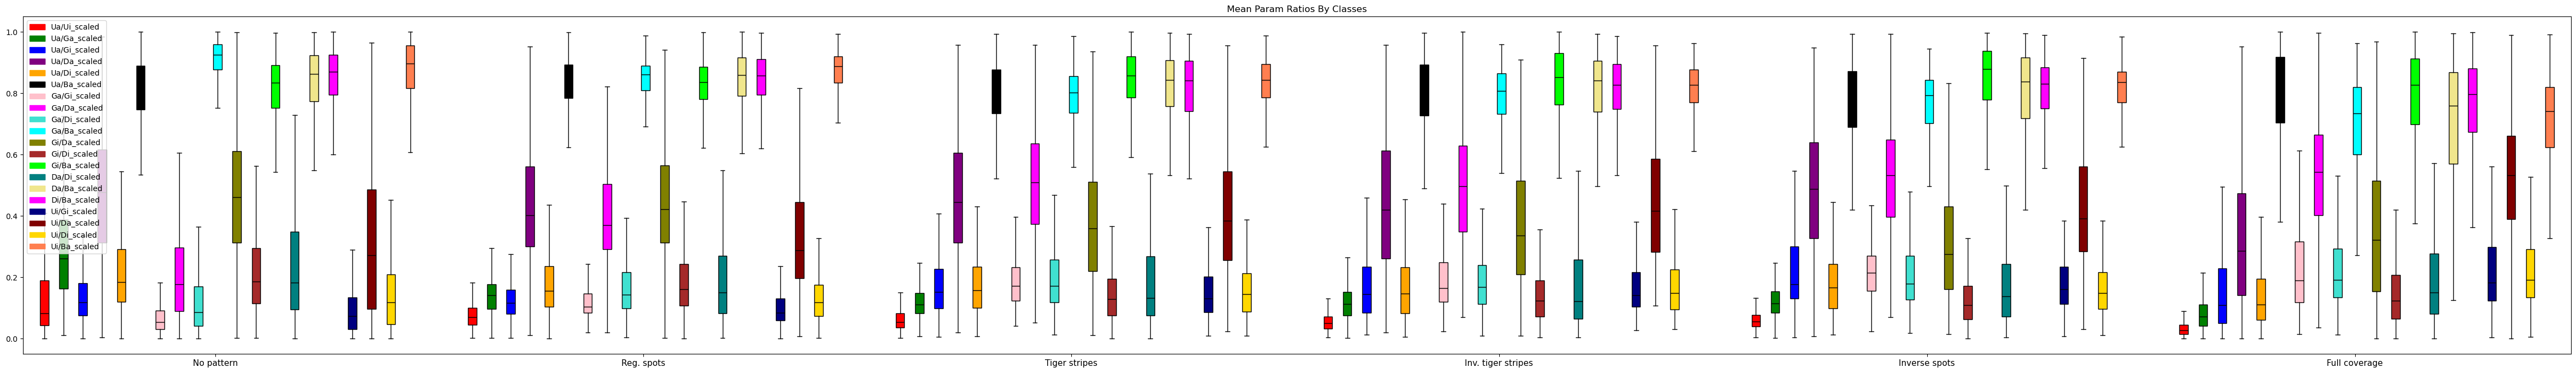

In [314]:
# print box plots for all scaled ratios based on class 
print("\n\nNow plotting mean scaled parameter ratios by class: ")

ratios_list = ratios_scaled.tolist()

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (60,8))
data = []

positions = np.arange(0, num_classes*len(ratios_list)) * .45
position_counter = 0

for i in presentation_order:
  class_df = class_dfs[i]

  for feat in ratios_list:
    df = class_df[feat]
    data.append(df)

    offset = position_counter // len(ratios_list)
    positions[position_counter] += offset
    position_counter += 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='black'))

for patch, color in zip(bp['boxes'], colors*num_classes):
  patch.set_facecolor(color)
    
ax.set(title = "Mean Param Ratios By Classes")
xticks = [4+i*10 for i in range(len(presentation_order))]
ax.set_xticks(xticks)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(ratios_list, loc="upper left")
leg = ax.get_legend()

for idx in range(len(colors)): 
    leg.legend_handles[idx].set_color(colors[idx])

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Mean_All_Ratios_Scaled_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()



Now plotting mean scaled parameter values by class: 


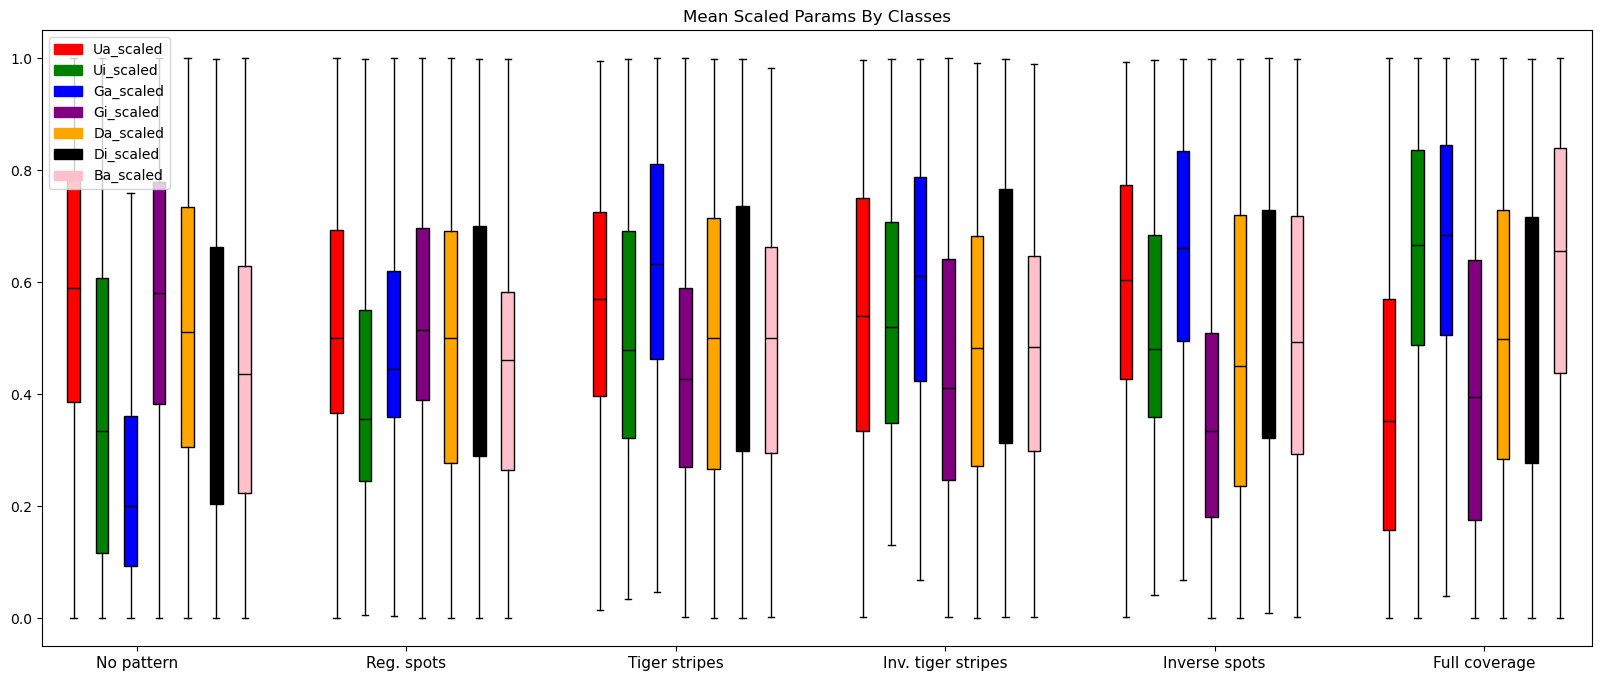

In [296]:
# print box plots for all 7 main params based on class 
print("\n\nNow plotting mean scaled parameter values by class: ")

feats_list = feats_scaled.tolist()

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (20,8))
data = []

positions = np.arange(0, len(feats_list)*num_classes) * 0.45

position_counter = 0
for i in presentation_order:
  class_df = class_dfs[i]

  for feat in feats_list:
    df = class_df[feat]
    data.append(df)

    offset = position_counter // len(feats_list)
    positions[position_counter] += offset
    position_counter += 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='black'))

colors = [colors[i] for i in range(len(feats_list))]
for patch, color in zip(bp['boxes'], colors*num_classes):
  patch.set_facecolor(color)
    
ax.set(title = "Mean Scaled Params By Classes")
xticks = [1+i*4.25 for i in range(len(presentation_order))]
ax.set_xticks(xticks)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(feats_list, loc="upper left")
leg = ax.get_legend()

for idx in range(len(colors)): 
    leg.legend_handles[idx].set_color(colors[idx])

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Mean_All_Params_Scaled_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

lin_reg=LinearRegression()
lin_reg.fit(feat_1,param_1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
model = LinearRegression()

 #define predictor and response variables
feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

# fit linear regression model
model.fit(param_1, feat_1)

#calculate R-squared (value indicating how well the data fits the regression model)
r_squared = model.score(param_1, feat_1)
print(r_squared)

0.026685643102544843


In [ ]:
# calculate R-squared value for all features vs all params
all_params = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']
feats = list(feats_df.columns[13:end_feats])

p_list = []
f_list = []
r2 = []

for param in all_params:
  for feat in feats:
    model = LinearRegression()

    feat_1 = np.array(feats_df[feat]).reshape(-1,1)
    param_1 = np.array(feats_df[param]).reshape(-1,1)

    model.fit(param_1, feat_1)

    r_squared = model.score(param_1, feat_1)

    r2.append(r_squared)
    p_list.append(param)
    f_list.append(feat)

r2_dic = {"feat": f_list,"param":p_list,"r2":r2}
r2_df = pd.DataFrame(r2_dic)
r2_df.head()

,feat,param,r2
0,num_spots,Ua,0.026686
1,Mean,Ua,0.094981
2,Median,Ua,0.080573
3,Area_mean,Ua,0.008368
4,Area_std,Ua,0.000009


In [27]:
output_dir = "data/R2_Values/"
os.makedirs(output_dir, exist_ok=True)

# prints highest to lowest R-squared values for given feature
r2_sorted = r2_df.sort_values(by=['r2'], ascending = False)

# save full list of R2 values in descending order
pd.set_option('display.float_format', '{:.05f}'.format)
print(r2_sorted.to_string(index=False))
r2_sorted.to_csv(output_dir + "Feature_Param_R2.txt", sep='\t', index=False, header=True)

# save R2 values in descending order for each param in separate files
folder_name = "R2_Values_By_Param/"
os.makedirs(output_dir + folder_name, exist_ok=True)

for param in all_params:
    r2_param = r2_sorted[r2_sorted["param"] == param]
    r2_param = r2_param.reset_index(drop = True)
    r2_param.to_csv(output_dir + folder_name + param.replace("/","-") + "_R2.txt", sep='\t', index=False, header=True)

# save R2 values in descending order for each feature in separate files
folder_name = "R2_Values_By_Feature/"
os.makedirs(output_dir + folder_name, exist_ok=True)

for feat in feats:
    r2_feat = r2_sorted[r2_sorted["feat"] == feat]
    r2_feat = r2_feat.reset_index(drop = True)
    r2_feat.to_csv(output_dir + folder_name + feat + "_R2.txt", sep='\t', index=False, header=True)

                    feat param      r2
               %Area_std Da/Ba 1.00000
               %Area_std Ui/Ba 1.00000
      %Area_inverted_std Ga/Da 1.00000
               %Area_std Ga/Gi 1.00000
               %Area_std Ga/Di 1.00000
      %Area_inverted_std Ga/Di 1.00000
      %Area_inverted_std Ua/Di 1.00000
               %Area_std Ga/Ba 1.00000
               %Area_std    Di 1.00000
               %Area_std Gi/Di 1.00000
      %Area_inverted_std Ga/Ba 1.00000
               %Area_std Gi/Da 1.00000
      %Area_inverted_std    Ga 1.00000
      %Area_inverted_std Ua/Gi 1.00000
      %Area_inverted_std Gi/Da 1.00000
               %Area_std Ua/Di 1.00000
               %Area_std    Ga 1.00000
      %Area_inverted_std    Ua 1.00000
      %Area_inverted_std Ui/Gi 1.00000
      %Area_inverted_std Ui/Di 1.00000
               %Area_std    Ba 1.00000
               %Area_std Ua/Ga 1.00000
               %Area_std Ua/Ba 1.00000
      %Area_inverted_std Ua/Ba 1.00000
               %Area_std 



Now plotting parameters by class in the feature space: 


KeyboardInterrupt: 

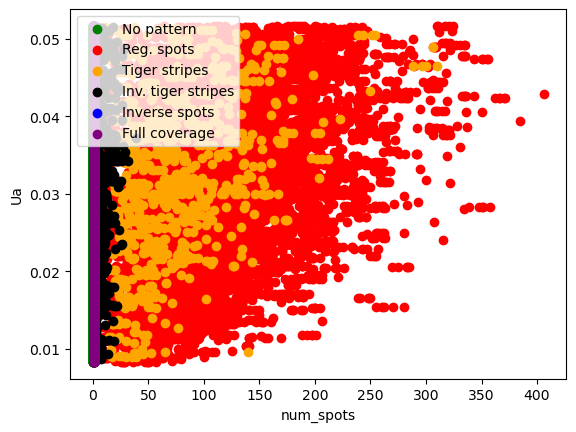

In [28]:
# plot the model predicted class in feature space
print("\n\nNow plotting parameters by class in the feature space: ")

folder_name = "Param_By_Class_in_Feature_Space/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

# features from num_spots to solidity_std
image_features = list(feats_df.columns[13:62])

classes = np.arange(0,num_classes)

for feat in image_features:
  for param in params:
    feat_1 = feat
    feat_2 = param

    fig, ax = plt.subplots()

    alpha = [1,1,1,1,1,1,1,1,1,1]
    for j in presentation_order:
      df = class_dfs[j]
      ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = legend_presentation_names[j], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2)

    # option_print = True
    if "/" in feat_2:
      feat_2 = feat_2.replace("/","-")
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300, bbox_inches="tight")
      plt.close()
    else:
      plt.show()

if option_print:
  print("Parameters in feature space plots are saved.")

In [ ]:
# file that contains dataframe of features for each param value when other param values don't change; doesn't contain cluster info
with open("data/single_param_scans.pkl", 'rb') as f:
  single_dic = pickle.load(f) # deserialize using load()

In [ ]:
single_dic["Ui"].head(20)

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std
0,0.03,0.03585858585858586,0.08,0.1,-0.12,0.01,0.5,0,2,14936.png,14936,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
1,0.03,0.03671717171717172,0.08,0.1,-0.12,0.01,0.5,0,2,14937.png,14937,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
2,0.03,0.03757575757575758,0.08,0.1,-0.12,0.01,0.5,0,2,14938.png,14938,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
3,0.03,0.03843434343434344,0.08,0.1,-0.12,0.01,0.5,0,2,14939.png,14939,/content/05-0

In [ ]:
# create a new dictionary containing the cluster info by searching for the paths in feats_df_large
# note: this is not on the narrow param domain like before
indices = {"Ua":[],"Ui":[],"Ga":[],"Gi":[],"Da":[],"Di":[],"Ba":[]}

for i in single_dic.keys():
    df = single_dic[i]
    df.reset_index(inplace=True, drop=True)
    for j in range(df.shape[0]):
        path = df["path"][j]
        line = feats_df_large[feats_df_large["path"] == path]
        indices[i].append(line.index[0])

single_classes = {"Ua":None,"Ui":None,"Ga":None,"Gi":None,"Da":None,"Di":None,"Ba":None}

for i in indices.keys():
  ind_list = indices[i]
  df = feats_df_large.iloc[ind_list]
  df.reset_index(inplace = True, drop = True)
  single_classes[i] = df

In [ ]:
# now shows dataframe with cluster info
single_classes["Ua"].head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.0067,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14735.png,14735,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,3
1,0.006834343434343434,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14736.png,14736,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,3
2,0.006968686868686869,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14737.png,14737,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,3
3,0.007103030303030303,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14738.png,14738,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,3
4,0.007237373737373738,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14739.png,14739,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0



Now printing images per parameter from single parameter scans: 


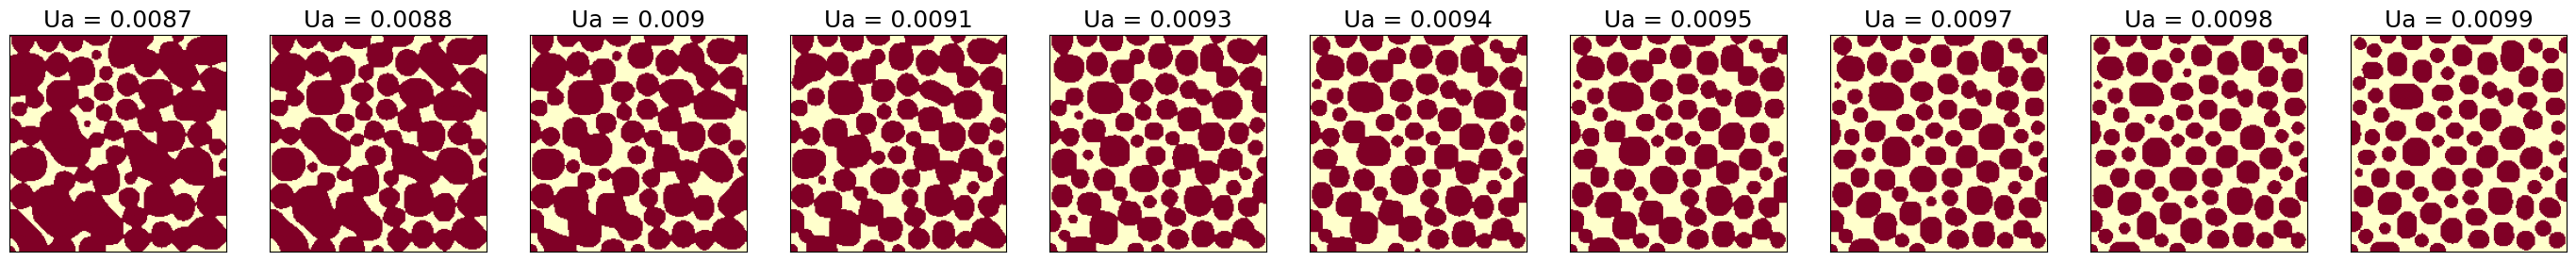

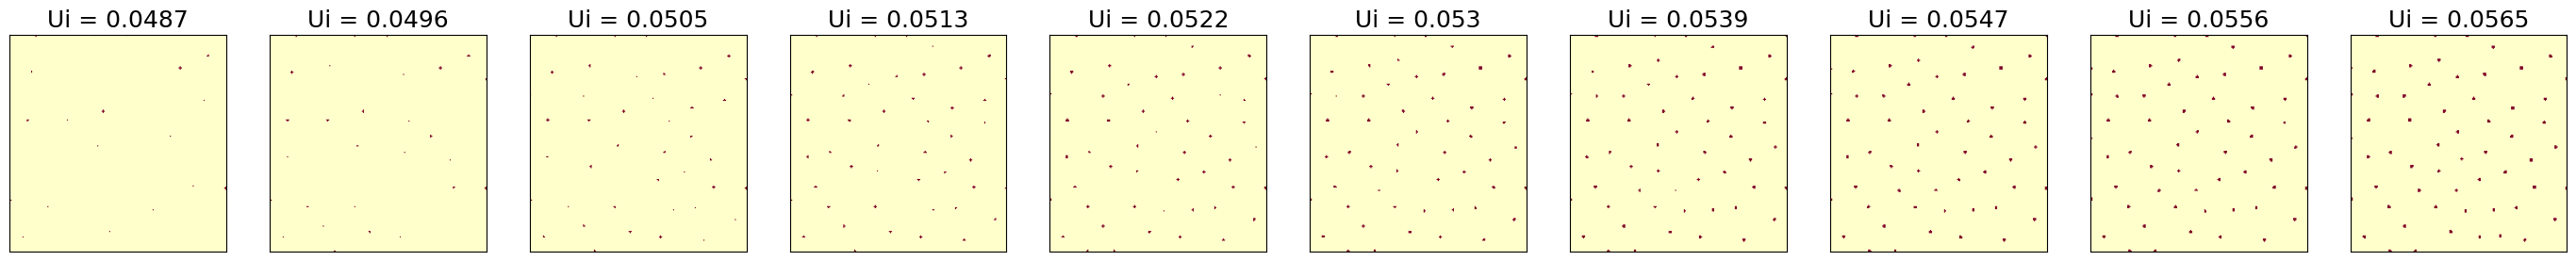

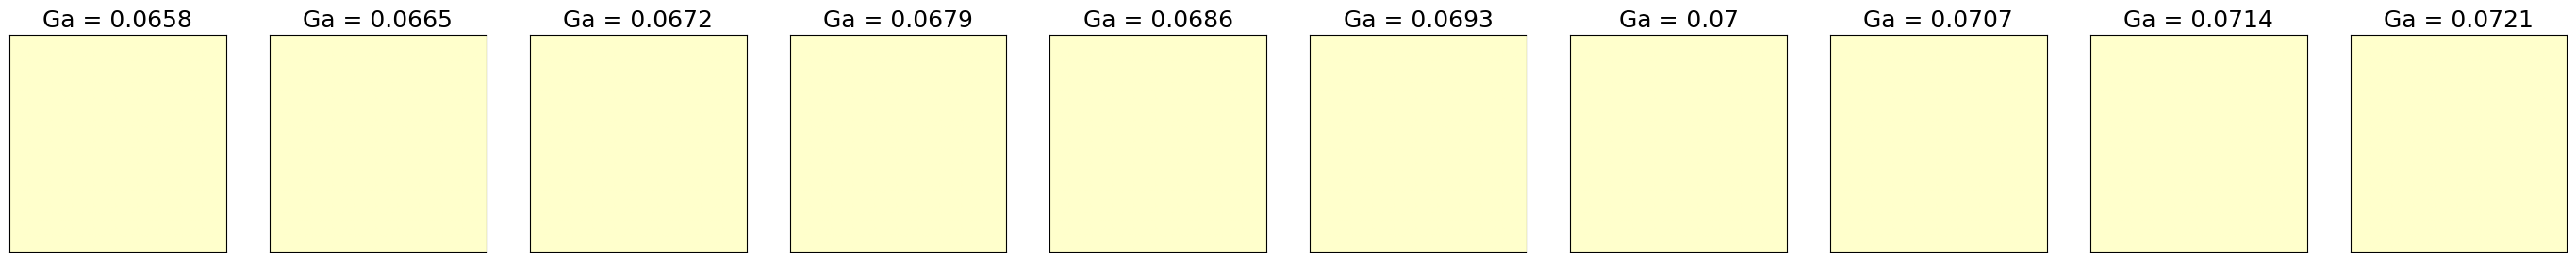

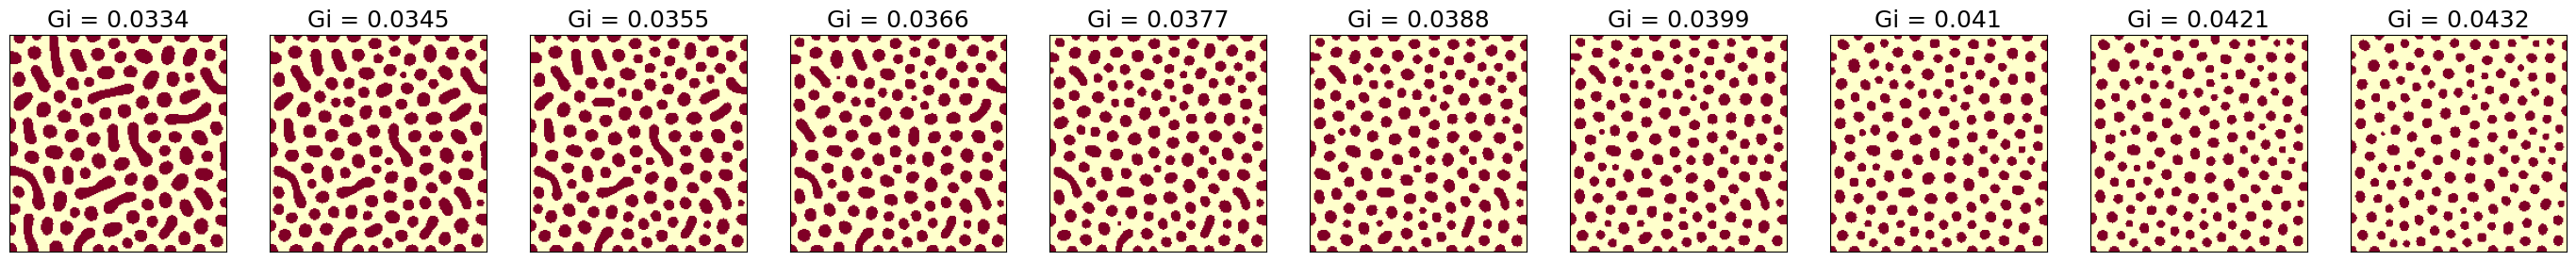

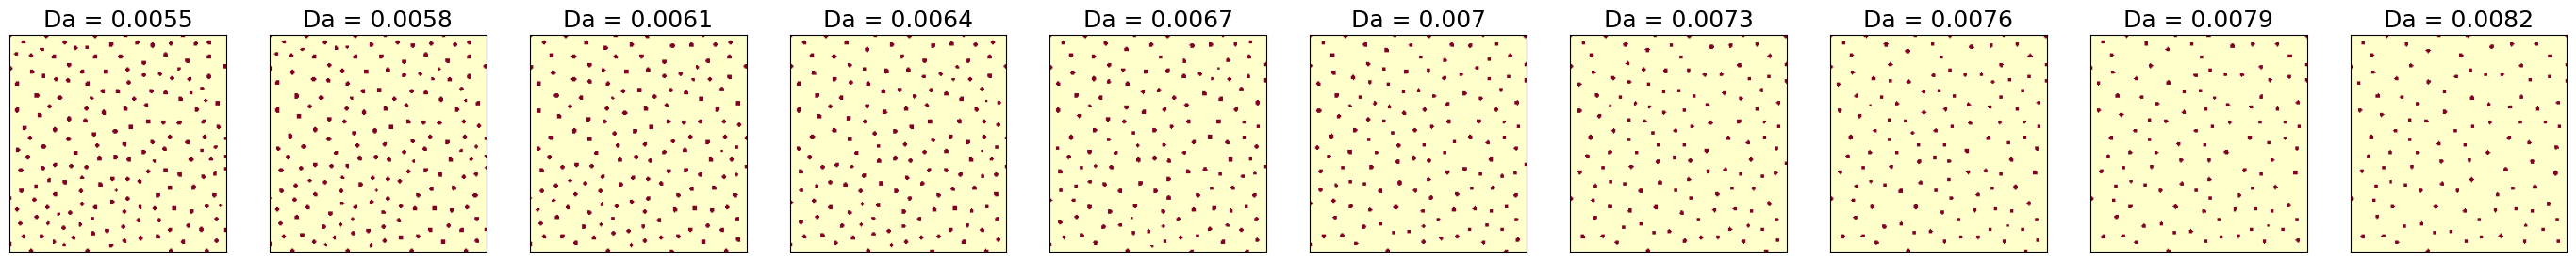

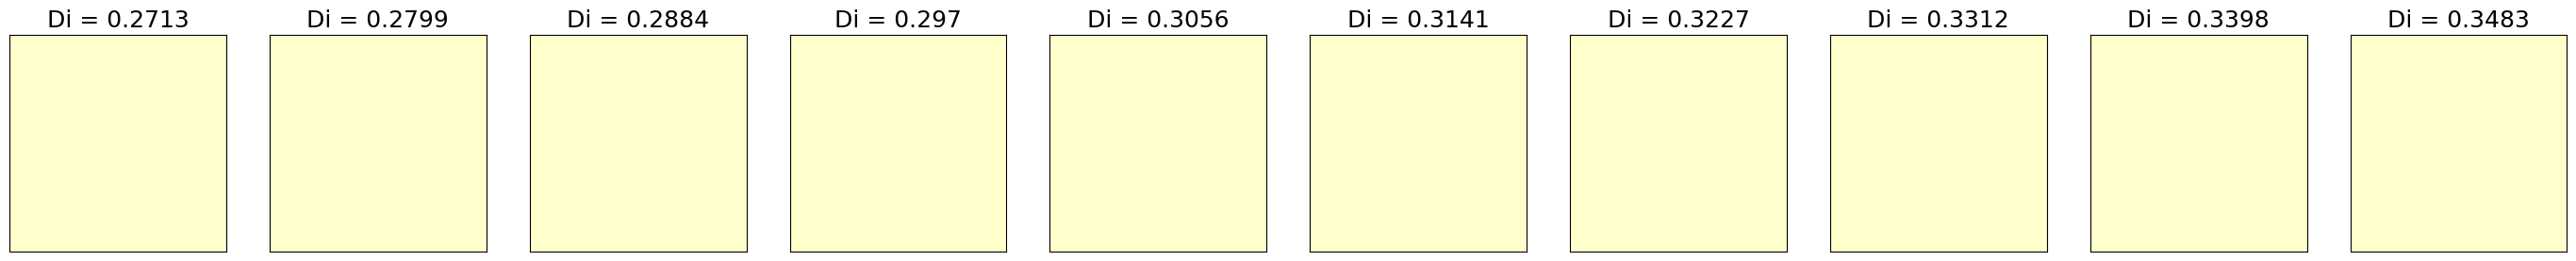

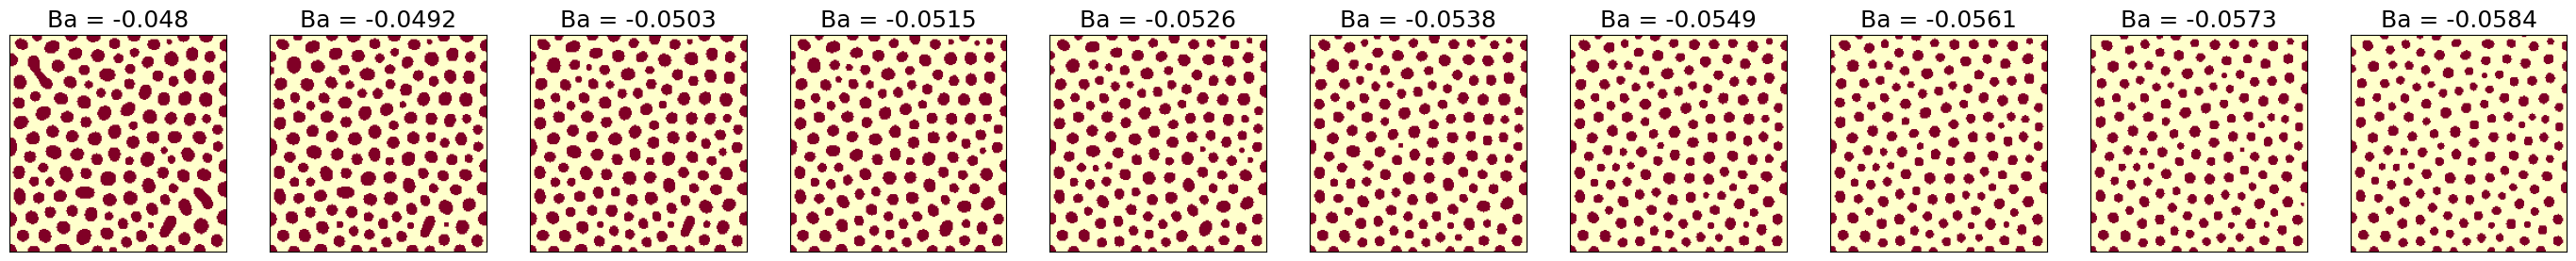

In [ ]:
print("\n\nNow printing images per parameter from single parameter scans: ")

folder_name = "Single_Param_Scans_Images_By_Parameter/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

#sort all the dfs
for i in single_classes.keys():
  df = single_classes[i].copy()
  df[params] = df[params].astype(float)
  df = df.sort_values(by = i)
  single_classes[i] = df

# print out random images from clusters
num_imgs = 10
skip = 15

for i in range(len(params)):
  fig, ax = plt.subplots(1,num_imgs)
  for j in range(num_imgs):
    df = single_classes[params[i]]
    path = df["dir"][j+skip] + df["path"][j+skip]
    img = np.array(Image.open(path[1:]))
    ax[j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[j].set_title(str(params[i]) + " = "+ str(df[params[i]][j+skip].round(4)), fontsize = 18)
    ax[j].get_xaxis().set_visible(False)
    ax[j].get_yaxis().set_visible(False)
   
  fig.set_figwidth(5*len(params))
  fig.set_figheight(num_imgs)

  option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + str(params[i]) + "_Skip" + str(skip) + ".png", dpi = 300, bbox_inches="tight", pad_inches=0.5)
  plt.show()


In [ ]:
# plot some dependencies
print("\n\nNow plotting features against parameters in single parameter scans: ")

folder_name = "Linear_Scans_Feat_vs_Param/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

keys = list(single_classes.keys())

# iterate through params
for feat in image_features:
  for i in range(len(keys)):
    fig, ax = plt.subplots()
    # iterate through classes
    for j in presentation_order:
      # pull up the dataframe for the specific class
      df = single_classes[keys[i]]
      df = df[df["cluster"] == j]
      df.reset_index(inplace = True, drop = True)

      x = df[keys[i]].astype(float)
      y = df[feat].astype(float)

      ax.scatter(x,y, color = colors[j])
    ax.legend(presentation_names)
    ax.set(title = f"Dependency of {feat} on {keys[i]}", xlabel = keys[i], ylabel = feat)

    # option_print = True
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat + "_vs_" + keys[i] + "_SingleParamScan.png", dpi = 300, bbox_inches="tight")
      plt.close()
    else:
      plt.show()

if option_print:
  print("Linear scans and dependencies plots are saved.")    



Now plotting features against parameters in single parameter scans: 
Linear scans and dependencies plots are saved.
